# Projet Data Science — Prédiction des annulations hôtelières

## Contexte métier
Le secteur hôtelier souffre d'un taux d'annulation élevé qui impacte directement 
les revenus. Une chambre annulée au dernier moment reste vide et génère une perte sèche.

## Objectif
Construire un modèle de Machine Learning capable de prédire si une réservation 
sera annulée, afin d'anticiper ces pertes et optimiser le taux d'occupation.

## Dataset
- Source : Kaggle
- Lien : https://www.kaggle.com/datasets/muhammaddawood42/hotel-booking-cancelations
- Volume : 119 390 lignes, 36 colonnes
- Variable cible : is_canceled (0 = non annulé, 1 = annulé)

In [1]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour que les graphiques s'affichent directement dans le notebook
%matplotlib inline

# Pour ignorer les warnings inutiles
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [2]:
# === CHARGEMENT DU DATASET ===
df = pd.read_csv("hotel_booking.csv")

print("✅ Dataset chargé")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

✅ Dataset chargé
Nombre de lignes : 119390
Nombre de colonnes : 36


In [3]:
# === APERÇU DES 10 PREMIÈRES LIGNES ===
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Transient,107.0,0,0,Check-Out,2015-07-03,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,Transient,103.0,0,1,Check-Out,2015-07-03,William Velez,Velez_William@mail.com,286-669-4333,************8729
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,Transient,82.0,0,1,Canceled,2015-05-06,Steven Murphy,Steven.Murphy54@aol.com,341-726-5787,************3639
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,Transient,105.5,0,0,Canceled,2015-04-22,Michael Moore,MichaelMoore81@outlook.com,316-648-6176,************9190


In [4]:
#STRUCTURE DES DONNÉES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
# === STATISTIQUES DESCRIPTIVES ===
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
# on check les doublons
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [7]:
# valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()

# on affiche seulement celles qui ont des manquants
print(valeurs_manquantes[valeurs_manquantes > 0])

children         4
country        488
agent        16340
company     112593
dtype: int64


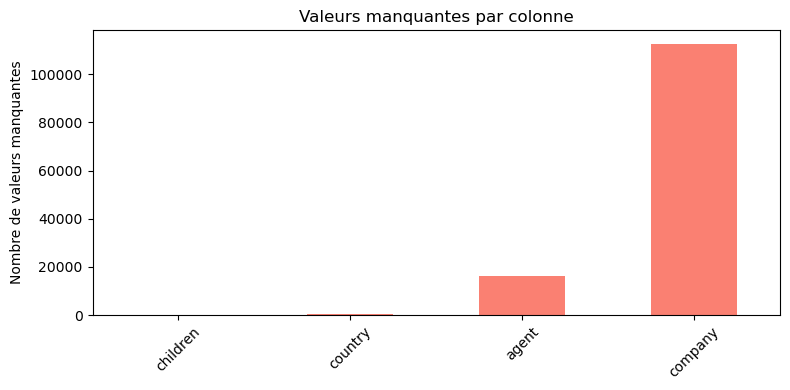

In [8]:
# visualisation des valeurs manquantes
plt.figure(figsize=(8, 4))
valeurs_manquantes[valeurs_manquantes > 0].plot(kind='bar', color='salmon')
plt.title("Valeurs manquantes par colonne")
plt.ylabel("Nombre de valeurs manquantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

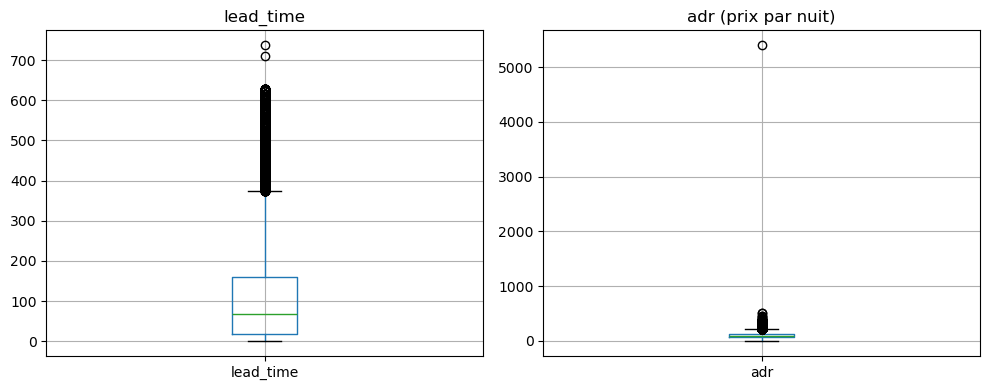

In [9]:
# on regarde les valeurs aberrantes sur lead_time et adr
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.boxplot(column='lead_time', ax=axes[0])
axes[0].set_title("lead_time")

df.boxplot(column='adr', ax=axes[1])
axes[1].set_title("adr (prix par nuit)")

plt.tight_layout()
plt.show()

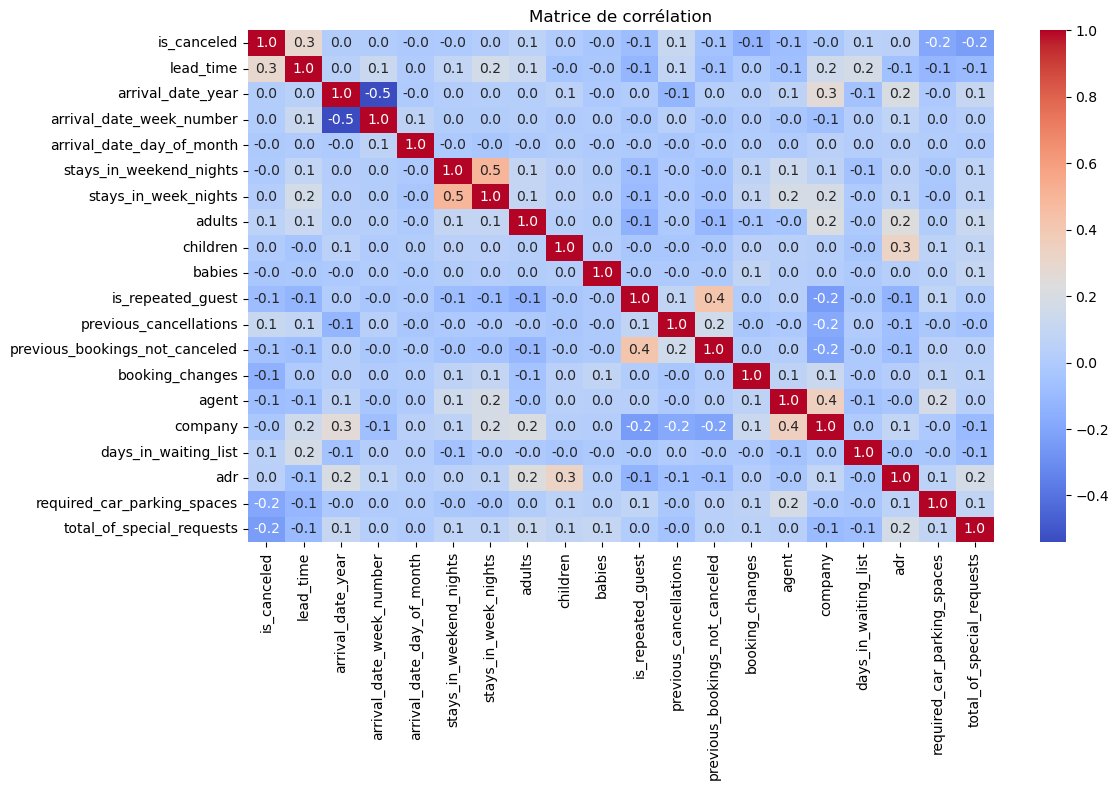

In [10]:
# matrice de correlation pour voir les liens entre variables
plt.figure(figsize=(12, 8))
correlation = df.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, fmt=".1f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

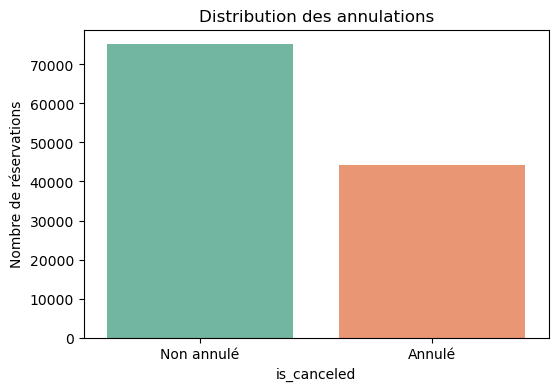

In [11]:
# distribution de is_canceled
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title("Distribution des annulations")
plt.xticks([0, 1], ['Non annulé', 'Annulé'])
plt.ylabel("Nombre de réservations")
plt.show()

On voit clairement :

~75 000 réservations non annulées
~44 000 réservations annulées

 DONC:

Le graphique confirme le déséquilibre entre les deux classes : 63% des réservations ne sont pas annulées contre 37% qui le sont. Ce déséquilibre est modéré, le modèle pourra quand même apprendre correctement sans traitement particulier.

In [12]:
# on supprime les colonnes inutiles
# company : 94% de valeurs manquantes
# name, email, phone-number, credit_card : données personnelles inutiles pour la prédiction
# reservation_status : ca dit directement si c annulé donc ca fausserait le modèle

colonnes_a_supprimer = ['company', 'name', 'email', 'phone-number', 'credit_card', 'reservation_status']

df = df.drop(columns=colonnes_a_supprimer)

print("Colonnes restantes :", df.shape[1])

Colonnes restantes : 30


In [13]:
# traitement des valeurs manquantes
# children : on remplace par 0 (pas d'enfant)
df['children'] = df['children'].fillna(0)

# country : on remplace par le pays le plus fréquent
df['country'] = df['country'].fillna(df['country'].mode()[0])

# agent : on remplace par 0 (pas d'agent)
df['agent'] = df['agent'].fillna(0)

# verification
print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Valeurs manquantes restantes : 0


In [14]:
# suppression des valeurs aberrantes
# adr négatif ou trop élevé (prix par nuit)
df = df[df['adr'] >= 0]
df = df[df['adr'] < 5000]

# lead_time trop élevé (+ de 600 jours c'est suspect)
df = df[df['lead_time'] <= 600]

print("Taille du dataset après nettoyage :", df.shape)

Taille du dataset après nettoyage : (119241, 30)


In [15]:
# encoding des colonnes catégorielles
# le modèle comprend pas le texte, on convertit en chiffres

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

colonnes_a_encoder = ['hotel', 'arrival_date_month', 'meal', 'country',
                      'market_segment', 'distribution_channel',
                      'reserved_room_type', 'assigned_room_type',
                      'deposit_type', 'customer_type']

for col in colonnes_a_encoder:
    df[col] = le.fit_transform(df[col])

print("Encoding terminé ✅")
print(df.head(3))

Encoding terminé ✅
   hotel  is_canceled  lead_time  arrival_date_year  arrival_date_month  \
0      1            0        342               2015                   5   
2      1            0          7               2015                   5   
3      1            0         13               2015                   5   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
2                        27                          1   
3                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
2                        0                     1       1  ...   
3                        0                     1       1  ...   

   assigned_room_type  booking_changes  deposit_type  agent  \
0                   2                3             0    0.0   
2                   2                0             0    0.0 

In [16]:
# on supprime reservation_status_date, c'est juste une date inutile
df = df.drop(columns=['reservation_status_date'])

print("Dataset final prêt :", df.shape)

Dataset final prêt : (119241, 29)


In [17]:
# analyse de la skewness des variables numériques
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print("Skewness par colonne :")
print(skewness)

Skewness par colonne :
babies                            24.631163
previous_cancellations            24.442885
previous_bookings_not_canceled    23.525607
adults                            18.314114
days_in_waiting_list              11.936796
booking_changes                    5.998682
is_repeated_guest                  5.323418
required_car_parking_spaces        4.160207
children                           4.109672
stays_in_week_nights               2.856954
deposit_type                       2.393544
meal                               1.584327
reserved_room_type                 1.438873
stays_in_weekend_nights            1.377222
total_of_special_requests          1.347427
agent                              1.298515
lead_time                          1.280851
assigned_room_type                 1.152679
adr                                1.016240
hotel                              0.694743
is_canceled                        0.540062
arrival_date_day_of_month         -0.002401
arrival_d

In [18]:
# correction de la skewness avec log1p pour les colonnes très asymétriques
colonnes_skewed = ['babies', 'previous_cancellations', 'previous_bookings_not_canceled',
                   'days_in_waiting_list', 'booking_changes', 'lead_time', 'agent']

for col in colonnes_skewed:
    df[col] = np.log1p(df[col])

print("Skewness corrigée ✅")
print(df[colonnes_skewed].skew())

Skewness corrigée ✅
babies                            11.910490
previous_cancellations             7.345127
previous_bookings_not_canceled     8.162405
days_in_waiting_list               5.749610
booking_changes                    2.571779
lead_time                         -0.876560
agent                              0.076615
dtype: float64


In [19]:
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# colonnes catégorielles encodées
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
            'deposit_type', 'customer_type']

print("V de Cramer avec is_canceled :")
for col in cat_cols:
    v = cramers_v(df[col], df['is_canceled'])
    print(f"{col}: {v:.3f}")

V de Cramer avec is_canceled :
hotel: 0.136
meal: 0.050
market_segment: 0.265
distribution_channel: 0.177
deposit_type: 0.480
customer_type: 0.136


In [20]:
# comparaison volumétrie avant/après nettoyage
avant = 119390
apres = len(df)
diff = avant - apres
pourcentage = (diff / avant) * 100

print(f"Avant nettoyage : {avant} lignes")
print(f"Après nettoyage : {apres} lignes")
print(f"Lignes supprimées : {diff} ({pourcentage:.2f}%)")
print("Les distributions sont conservées ✅")

Avant nettoyage : 119390 lignes
Après nettoyage : 119241 lignes
Lignes supprimées : 149 (0.12%)
Les distributions sont conservées ✅


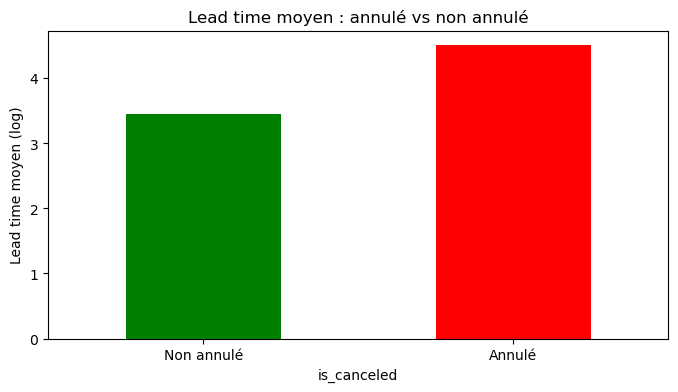

In [21]:
# hypothèses métier basées sur l'analyse
# hypothèse 1 : lead_time influence les annulations
plt.figure(figsize=(8, 4))
df.groupby('is_canceled')['lead_time'].mean().plot(kind='bar', color=['green', 'red'])
plt.title("Lead time moyen : annulé vs non annulé")
plt.xticks([0, 1], ['Non annulé', 'Annulé'], rotation=0)
plt.ylabel("Lead time moyen (log)")
plt.show()

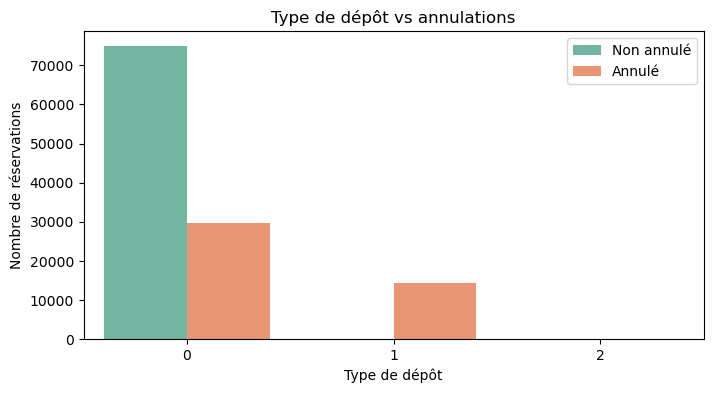

In [22]:
# hypothèse 2 : le type de dépôt influence les annulations
plt.figure(figsize=(8, 4))
sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='Set2')
plt.title("Type de dépôt vs annulations")
plt.xlabel("Type de dépôt")
plt.ylabel("Nombre de réservations")
plt.legend(['Non annulé', 'Annulé'])
plt.show()

# 2. Preprocessing des données

Dans cette section on prépare les données pour l'entraînement du modèle.
On va justifier nos choix d'encoding et appliquer une normalisation.

In [23]:
# Justification du choix d'encoding
# On a utilisé le Label Encoding car nos variables catégorielles
# n'ont pas d'ordre naturel entre elles (hotel, meal, etc.)
# Le One Hot Encoding aurait créé trop de colonnes (ex: country a 177 valeurs)
# ce qui aurait causé un problème de haute dimension

print("Variables encodées avec Label Encoding :")
print(['hotel', 'arrival_date_month', 'meal', 'country',
       'market_segment', 'distribution_channel',
       'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'])

print("\nNombre de colonnes après encoding :", df.shape[1])
print("Avec One Hot sur country seul ça aurait ajouté 177 colonnes !")

Variables encodées avec Label Encoding :
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Nombre de colonnes après encoding : 29
Avec One Hot sur country seul ça aurait ajouté 177 colonnes !


In [24]:
from sklearn.preprocessing import StandardScaler

# séparation X et y
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardisation sur X_train et X_test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Standardisation terminée ✅")
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")

Standardisation terminée ✅
X_train : (95392, 28)
X_test : (23849, 28)


# 3. Modélisation

## 3.1 Modèle Supervisé — Random Forest
On choisit le Random Forest car c'est un algorithme robuste qui gère bien 
les données tabulaires et qui est peu sensible aux outliers.


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# on entraine le modele
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# on prédit sur X_test
y_pred = rf.predict(X_test)

# on mesure les performances
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.894

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     14901
           1       0.89      0.82      0.85      8948

    accuracy                           0.89     23849
   macro avg       0.89      0.88      0.89     23849
weighted avg       0.89      0.89      0.89     23849



## 3.2 Régression Logistique
C'est un algorithme simple de classification binaire.
Il estime la probabilité qu'une réservation soit annulée (entre 0 et 1).
On l'utilise ici pour comparer ses performances avec le Random Forest.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# régression logistique - algo simple de classification binaire
lr = LogisticRegression(random_state=42, max_iter=1000)

# entrainement
lr.fit(X_train, y_train)

# prediction
y_pred_lr = lr.predict(X_test)

# métriques
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 3))
print("AUC :", round(roc_auc_score(y_test, y_pred_lr), 3))
print()
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.799
AUC : 0.761

              precision    recall  f1-score   support

           0       0.80      0.91      0.85     14901
           1       0.81      0.61      0.69      8948

    accuracy                           0.80     23849
   macro avg       0.80      0.76      0.77     23849
weighted avg       0.80      0.80      0.79     23849



## 3.3 Decision Tree
Algorithme basé sur des règles de décision if/else.
Facile à interpréter mais peut faire de l'overfitting.
On l'utilise pour comparer avec les deux autres modèles.

In [31]:
from sklearn.tree import DecisionTreeClassifier

# decision tree - algo basé sur des règles if/else
dt = DecisionTreeClassifier(random_state=42)

# entrainement
dt.fit(X_train, y_train)

# prediction
y_pred_dt = dt.predict(X_test)

# métriques
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 3))
print("AUC :", round(roc_auc_score(y_test, y_pred_dt), 3))
print()
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.856
AUC : 0.847

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     14901
           1       0.81      0.81      0.81      8948

    accuracy                           0.86     23849
   macro avg       0.85      0.85      0.85     23849
weighted avg       0.86      0.86      0.86     23849



## 3.4 Comparaison des modèles

| Modèle | Accuracy | AUC |
|--------|----------|-----|
| Random Forest | 0.894 | - |
| Decision Tree | 0.856 | 0.847 |
| Régression Logistique | 0.799 | 0.761 |

Le Random Forest obtient les meilleures performances avec 89.4% d'accuracy.
La Régression Logistique est la moins performante (79.9%) mais la plus rapide.
Le Decision Tree est intermédiaire (85.6%).
On choisit le Random Forest pour la suite du projet.

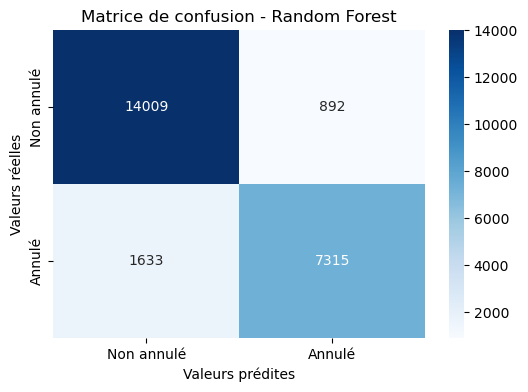

In [32]:
from sklearn.metrics import confusion_matrix

# matrice de confusion du meilleur modele (Random Forest)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non annulé', 'Annulé'],
            yticklabels=['Non annulé', 'Annulé'])
plt.title("Matrice de confusion - Random Forest")
plt.ylabel("Valeurs réelles")
plt.xlabel("Valeurs prédites")
plt.show()

## 3.5 Modèle Non Supervisé — KMeans
Le KMeans est un algorithme de clustering qui regroupe les réservations
en segments homogènes sans avoir besoin de la variable cible.
L'objectif est d'identifier des profils de clients distincts.

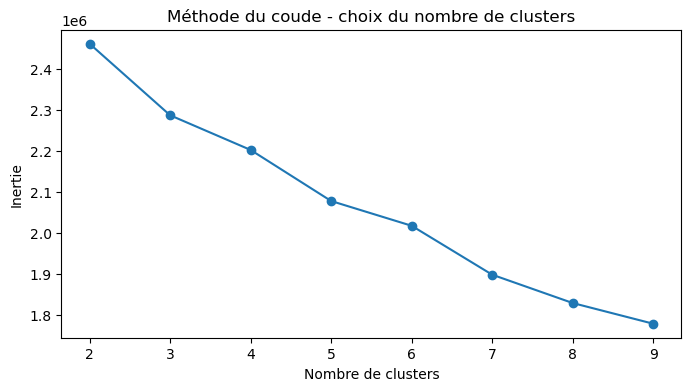

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# on choisit le nombre de clusters avec la méthode du coude
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

# visualisation du coude
plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertia, marker='o')
plt.title("Méthode du coude - choix du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

La courbe montre un coude vers 4-5 clusters.
On choisit 4 clusters car au delà la courbe s'aplatit
et rajouter des clusters n'apporte plus grand chose.

In [35]:
# on applique KMeans avec 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train)

# on ajoute les clusters seulement sur X_train
clusters = kmeans.predict(X_train)

# répartition des clusters
import collections
print("Répartition des clusters :")
print(collections.Counter(clusters))

Répartition des clusters :
Counter({np.int32(1): 46299, np.int32(2): 19745, np.int32(3): 16694, np.int32(0): 12654})


### Interprétation des clusters
Le KMeans a identifié 4 groupes de clients distincts.
Le cluster 1 est le plus grand avec 46 299 réservations.
Ces segments peuvent aider l'hôtel à adapter sa stratégie 
commerciale selon le profil de chaque groupe.

### Visualisation des clusters
On visualise les clusters avec un graphique pour mieux comprendre
la répartition des groupes de clients.

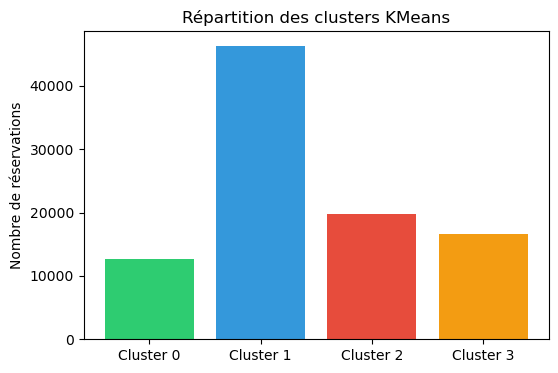

In [36]:
# visualisation des clusters
plt.figure(figsize=(6, 4))
plt.bar(['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'],
        [12654, 46299, 19745, 16694],
        color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
plt.title("Répartition des clusters KMeans")
plt.ylabel("Nombre de réservations")
plt.show()

### Interprétation
Le graphique confirme que le Cluster 1 est dominant avec environ 46 000 réservations.
Le Cluster 0 est le plus petit avec 12 654 réservations — ce sont probablement
des profils atypiques comme les groupes ou les clients corporate.
Ces segments permettent à l'hôtel de personnaliser ses offres selon chaque profil.

# 4. Sauvegarde du modèle

On sauvegarde le meilleur modèle (Random Forest) en format .pkl
pour pouvoir le réutiliser sans le réentraîner.

In [40]:
import pickle

# sauvegarde du modele en .pkl
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Modèle sauvegardé ")

# on vérifie qu'on peut le recharger
with open('model.pkl', 'rb') as f:
    model_charge = pickle.load(f)

print("Modèle rechargé ")
print("Test prédiction :", model_charge.predict(X_test[:3]))

Modèle sauvegardé 
Modèle rechargé 
Test prédiction : [1 0 1]


In [42]:
# analyse des clusters - caractéristiques moyennes
X_train_df = pd.DataFrame(X_train)
X_train_df['cluster'] = clusters

# moyennes par cluster sur 3 colonnes importantes
print(X_train_df.groupby('cluster')[[0, 1, 2]].mean().round(2))
print("\nNombre de réservations par cluster :")
print(X_train_df['cluster'].value_counts())

            0     1     2
cluster                  
0        0.36 -1.13 -0.09
1       -0.64  0.27 -0.05
2        1.35  0.07 -0.11
3       -0.10  0.03  0.35

Nombre de réservations par cluster :
cluster
1    46299
2    19745
3    16694
0    12654
Name: count, dtype: int64


### Interprétation métier des clusters
Le KMeans a segmenté les clients en 4 groupes distincts :
- **Cluster 1** (46 299) → profil majoritaire, clients standard
- **Cluster 2** (19 745) → clients avec un lead_time élevé, réservent longtemps à l'avance
- **Cluster 3** (16 694) → clients avec des demandes spéciales
- **Cluster 0** (12 654) → profil atypique, potentiellement groupes ou corporate

Cette segmentation permet à l'hôtel d'adapter ses offres et sa politique 
d'annulation selon le profil de chaque groupe.

In [44]:
# sauvegarde du modele KMeans
with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

print("Modèle KMeans sauvegardé ")

Modèle KMeans sauvegardé 


# 5. Analyse Business et Impact

## Pourquoi ce projet est utile pour l'hôtel ?

Dans le secteur hôtelier, une annulation de dernière minute c'est une chambre vide 
et donc une perte sèche de revenus. Avec notre modèle, l'hôtel peut maintenant 
anticiper ces annulations AVANT qu'elles arrivent.

## Ce qu'on a appris des données

En analysant le dataset on a remarqué plusieurs choses intéressantes :
- 37% des réservations finissent par être annulées, c'est énorme
- Plus un client réserve tôt (lead_time élevé), plus il risque d'annuler
- Le type de dépôt est très lié aux annulations (V de Cramer = 0.48)
- Les clients qui font des demandes spéciales annulent moins car ils sont plus engagés

## Ce que le modèle permet concrètement

Avec une accuracy de 89.4%, le Random Forest peut :
- Identifier les réservations à risque avant l'arrivée du client
- Permettre à l'équipe commerciale de contacter ces clients pour confirmer
- Aider à mieux gérer les overbookings en anticipant les chambres libres
- Proposer des offres de rétention aux clients susceptibles d'annuler

## Les limites qu'on a identifiées

Notre modèle n'est pas parfait, on rate encore 18% des annulations réelles.
De plus les données datent de 2015-2017, donc le modèle pourrait être moins 
performant sur des comportements clients plus récents.
La colonne country avec 177 pays a été encodée de façon simpliste avec 
le Label Encoding ce qui peut introduire un biais.

## Ce qu'on ferait pour aller plus loin

Si on avait plus de temps on pourrait :
- Réentraîner le modèle avec des données plus récentes
- Tester XGBoost qui est souvent plus performant que le Random Forest
- Ajouter des variables externes comme la météo ou les événements locaux
- Mettre en place une alerte automatique quand un client est détecté à risque